# Task 2 
# Neural Network 


**Using Bank Marketing Dataset**

The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).



**1- Import Libraries**

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl
import tensorflow 
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [5]:
df = pd.read_csv("bank-additional-full.csv")
df.head()


,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."


**Data is not comma seperated , it is colon seperated**

In [6]:
df = pd.read_csv("bank-additional-full.csv" , sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

**Check the label --> Supervised**

In [8]:
df['y']

0         no
1         no
2         no
3         no
4         no
        ... 
41183    yes
41184     no
41185     no
41186    yes
41187     no
Name: y, Length: 41188, dtype: object

**Label is category --> classification**

**Check nans**

In [11]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

**No missing values**

**Check duplicates**

In [12]:
df.duplicated().sum()

np.int64(12)

In [13]:
df[df.duplicated()]


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,0
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,0
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,0
20216,55,services,married,high.school,unknown,no,no,cellular,aug,mon,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.965,5228.1,0
20534,41,technician,married,professional.course,no,yes,no,cellular,aug,tue,...,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,0
25217,39,admin.,married,university.degree,no,no,no,cellular,nov,tue,...,2,999,0,nonexistent,-0.1,93.200,-42.0,4.153,5195.8,0
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,0
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,0


**Drop duplicates**

In [14]:
df = df.drop_duplicates(keep='first')

**Verify no duplicates**

In [16]:
df.duplicated().sum()

np.int64(0)

**Data correlation**

In [27]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()
print(corr_matrix)

                     age  duration  campaign     pdays  previous  \
age             1.000000 -0.000808  0.004622 -0.034381  0.024379   
duration       -0.000808  1.000000 -0.071765 -0.047556  0.020600   
campaign        0.004622 -0.071765  1.000000  0.052606 -0.079182   
pdays          -0.034381 -0.047556  0.052606  1.000000 -0.587508   
previous        0.024379  0.020600 -0.079182 -0.587508  1.000000   
emp.var.rate   -0.000242 -0.027941  0.150786  0.271063 -0.420587   
cons.price.idx  0.001009  0.005303  0.127826  0.078920 -0.203197   
cons.conf.idx   0.129075 -0.008126 -0.013657 -0.091374 -0.050929   
euribor3m       0.010852 -0.032861  0.135169  0.296946 -0.454571   
nr.employed    -0.017607 -0.044672  0.144129  0.372659 -0.501411   
y               0.030381  0.405297 -0.066361 -0.324948  0.230202   

                emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
age                -0.000242        0.001009       0.129075   0.010852   
duration           -0.027941       

**Encode the label**

In [9]:
df['y'] = LabelEncoder().fit_transform(df['y'])  

In [10]:
df['y']

0        0
1        0
2        0
3        0
4        0
        ..
41183    1
41184    0
41185    0
41186    1
41187    0
Name: y, Length: 41188, dtype: int64

**Encode other categorical data**

In [21]:
df = pd.get_dummies(df, drop_first=True)  

**Check Distributions**

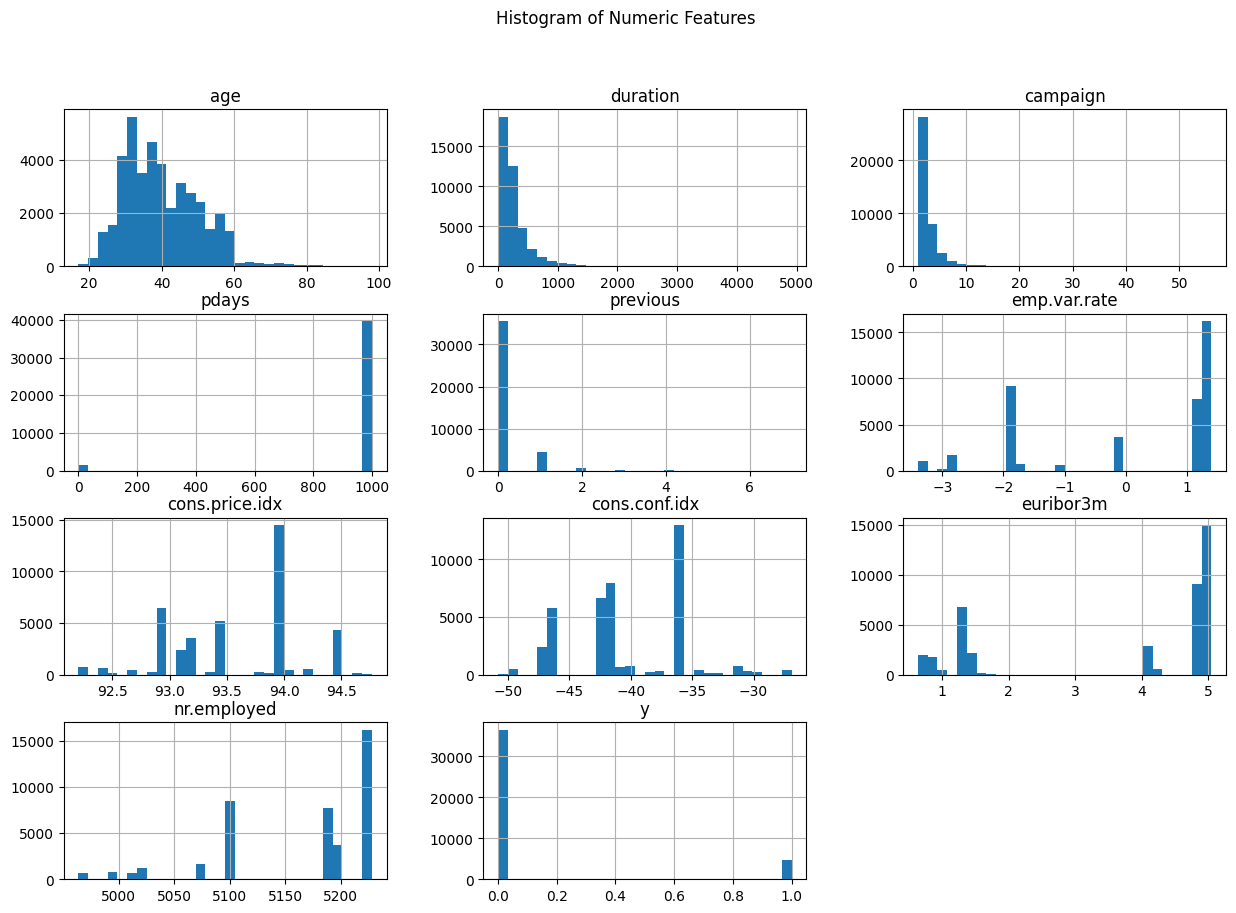

In [22]:
df[numeric_cols].hist(bins=30, figsize=(15,10))
plt.suptitle("Histogram of Numeric Features")
plt.show()

**Box plots to check outliers**

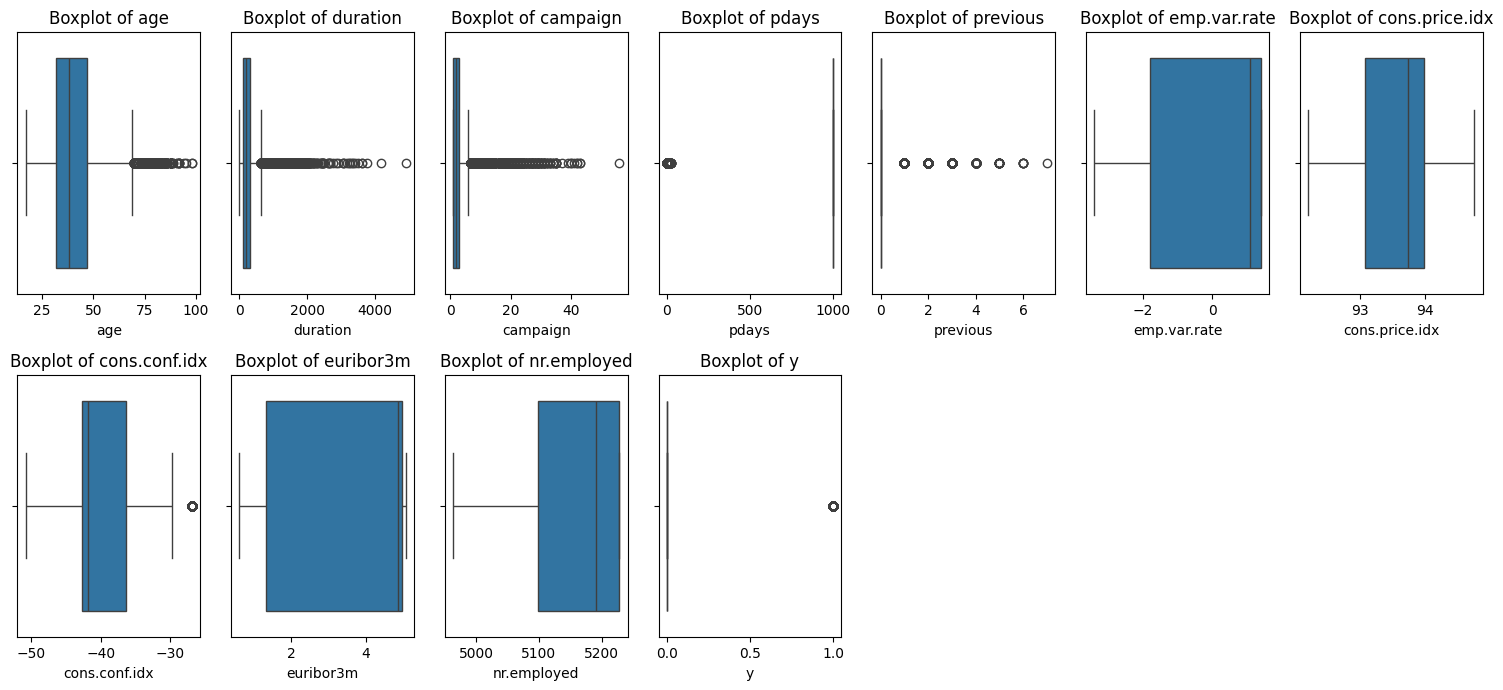

In [ ]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 7, i)  
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

**Scale Numerical Features**

In [28]:
scaler = RobustScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

**Split the data**

In [30]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train shape: {X_train.shape}, Validation shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (28823, 53), Validation shape: (6176, 53), Test shape: (6177, 53)


# Applying Golden Rules

**1-Few Data -> Simple Model**

In [32]:
X_small = X_train.sample(frac=0.05, random_state=42)
y_small = y_train.loc[X_small.index]

model_simple = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(1, activation='sigmoid')
])

model_simple.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_small = model_simple.fit(
    X_small, y_small,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=16
)

c:\Users\hazem\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8570 - loss: 1.4108 - val_accuracy: 0.8962 - val_loss: 0.4034
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8966 - loss: 0.3442 - val_accuracy: 0.8871 - val_loss: 0.3228
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9035 - loss: 0.2811 - val_accuracy: 0.8952 - val_loss: 0.2806
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9022 - loss: 0.2575 - val_accuracy: 0.8965 - val_loss: 0.2756
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9042 - loss: 0.2438 - val_accuracy: 0.8952 - val_loss: 0.2431
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9105 - loss: 0.2124 - val_accuracy: 0.9001 - val_loss: 0.2499
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9112 - loss: 0.2111 - val_accuracy: 0.9011 - val_loss: 0.2336
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9091 - loss: 0.2188 - val_accuracy: 0.9014 - val_lo

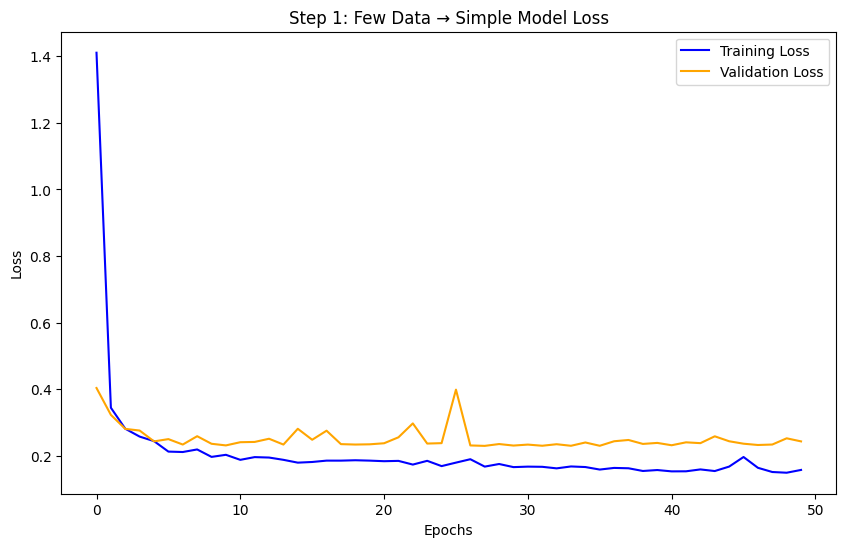

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(history_small.history['loss'], label='Training Loss', color='blue')
plt.plot(history_small.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Step 1: Few Data → Simple Model Loss')
plt.legend()
plt.show()

**Training loss decreases steadily which shows that the model is learning the small subset**



**Validation loss is lower than training initially but fluctuates which shows that the model cannot generalize well from so few samples**

**2-Full Data -> Simple model**

In [37]:
history_full_simple = model_simple.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,  
    batch_size=32
)

Epoch 1/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9207 - loss: 0.1696 - val_accuracy: 0.9067 - val_loss: 0.1999
Epoch 2/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9194 - loss: 0.1706 - val_accuracy: 0.9067 - val_loss: 0.2005
Epoch 3/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9202 - loss: 0.1702 - val_accuracy: 0.9064 - val_loss: 0.1913
Epoch 4/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9194 - loss: 0.1706 - val_accuracy: 0.9066 - val_loss: 0.1922
Epoch 5/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9190 - loss: 0.1702 - val_accuracy: 0.9064 - val_loss: 0.1879
Epoch 6/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9201 - loss: 0.1692 - val_accuracy: 0.9093 - val_loss: 0.1898
Epoch 7/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9200 - loss: 0.1690 - val_accuracy: 0.9066 - val_loss: 0.1887
Epoch 8/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9208 - loss: 0.1684 - val_accuracy: 0.

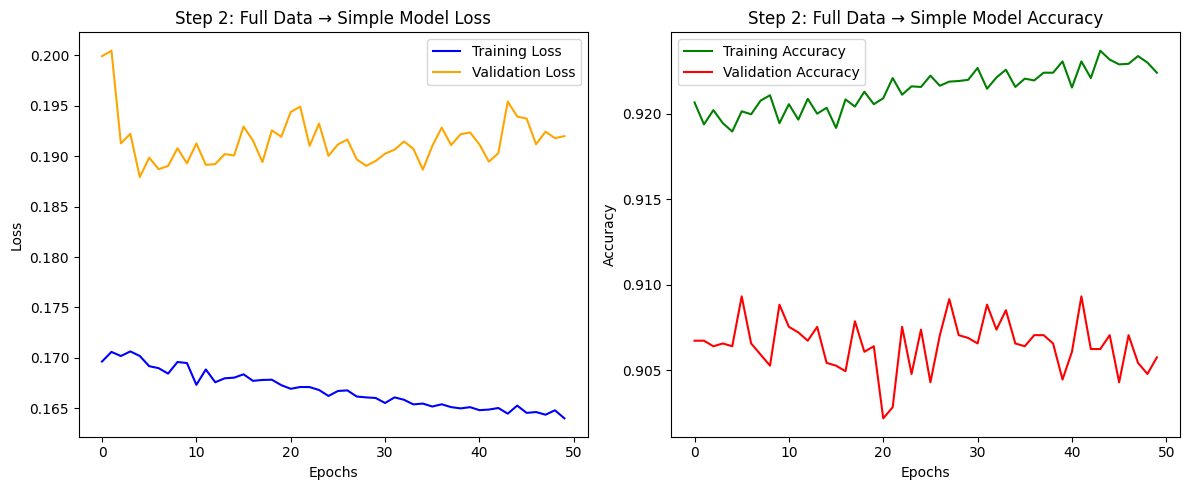

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_full_simple.history['loss'], label='Training Loss', color='blue')
plt.plot(history_full_simple.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Step 2: Full Data → Simple Model Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_full_simple.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history_full_simple.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Step 2: Full Data → Simple Model Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

The model is basically memorized the data instead of actually learning. You can see this clearly because training accuracy keeps going up while validation accuracy just flatlines around 90.7% and won't change no matter how many epochs you run. That gap between the two curves is the problem. The fix is what comes next: make the model deeper (Step 3) then add regularization (Step 4) to force it to actually generalize.

**3-Full data -> complex model**

In [40]:
model_complex = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  
    Dense(32, activation='relu'),                                    
    Dense(16, activation='relu'),                                    
    Dense(1, activation='sigmoid')                                 
])

model_complex.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_complex = model_complex.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50


c:\Users\hazem\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


901/901 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9019 - loss: 0.2652 - val_accuracy: 0.9037 - val_loss: 0.1989
Epoch 2/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9060 - loss: 0.2038 - val_accuracy: 0.9017 - val_loss: 0.1978
Epoch 3/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9072 - loss: 0.1907 - val_accuracy: 0.9040 - val_loss: 0.1938
Epoch 4/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9036 - loss: 0.1856 - val_accuracy: 0.8933 - val_loss: 0.1928
Epoch 5/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9091 - loss: 0.1798 - val_accuracy: 0.9043 - val_loss: 0.1914
Epoch 6/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9146 - loss: 0.1772 - val_accuracy: 0.9062 - val_loss: 0.1886
Epoch 7/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9141 - loss: 0.1755 - val_accuracy: 0.9074 - val_loss: 0.1890
Epoch 8/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9156 - loss: 0.1730 - val_accuracy: 0.9054 - val_

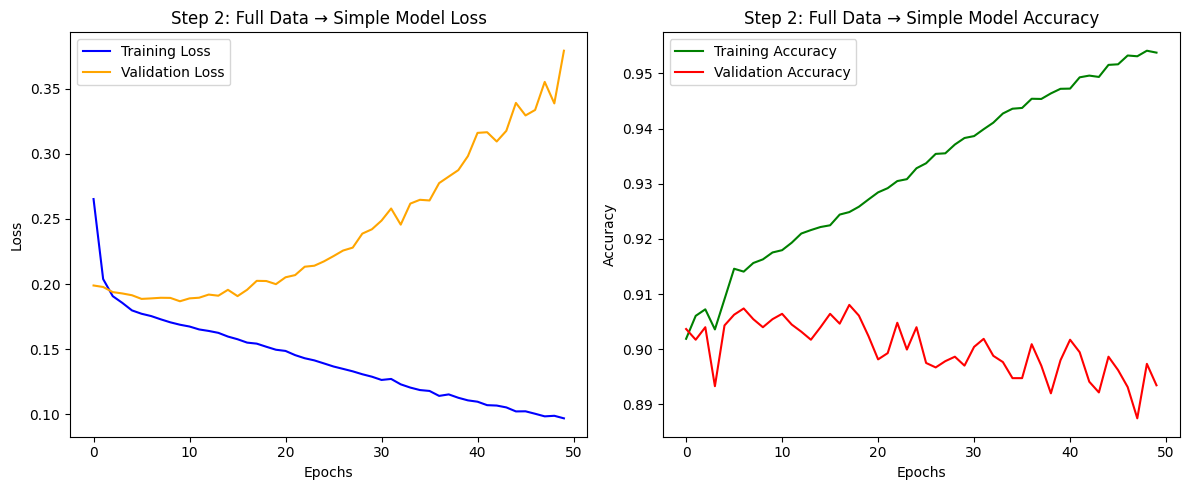

In [41]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_complex.history['loss'], label='Training Loss', color='blue')
plt.plot(history_complex.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Step 2: Full Data → Simple Model Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(history_complex.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history_complex.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Step 2: Full Data → Simple Model Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

This one is actually worse than the previous plot. The model is memorizing the training data so hard that it can't generalize well on new data as training goes on — you can see the validation loss  going up while training loss goes down, and validation accuracy slowly drifting down over time. Actions ->   need to stop training much earlier, and start regularization in the next step.

**4-Full data -> Complex Model**

In [42]:
from tensorflow.keras.layers import Dense, Dropout

model_complex_reg = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),                    # drop 30% of neurons randomly
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile
model_complex_reg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history_complex_reg = model_complex_reg.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50


c:\Users\hazem\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


901/901 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8963 - loss: 0.6245 - val_accuracy: 0.9030 - val_loss: 0.2170
Epoch 2/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9001 - loss: 0.2333 - val_accuracy: 0.9050 - val_loss: 0.1988
Epoch 3/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9000 - loss: 0.2025 - val_accuracy: 0.9048 - val_loss: 0.1979
Epoch 4/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9017 - loss: 0.1975 - val_accuracy: 0.8928 - val_loss: 0.2001
Epoch 5/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9020 - loss: 0.1936 - val_accuracy: 0.9040 - val_loss: 0.1945
Epoch 6/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9056 - loss: 0.1893 - val_accuracy: 0.9058 - val_loss: 0.1945
Epoch 7/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9067 - loss: 0.1886 - val_accuracy: 0.8941 - val_loss: 0.1955
Epoch 8/50
901/901 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9091 - loss: 0.1881 - val_accuracy: 0.9050 - val_

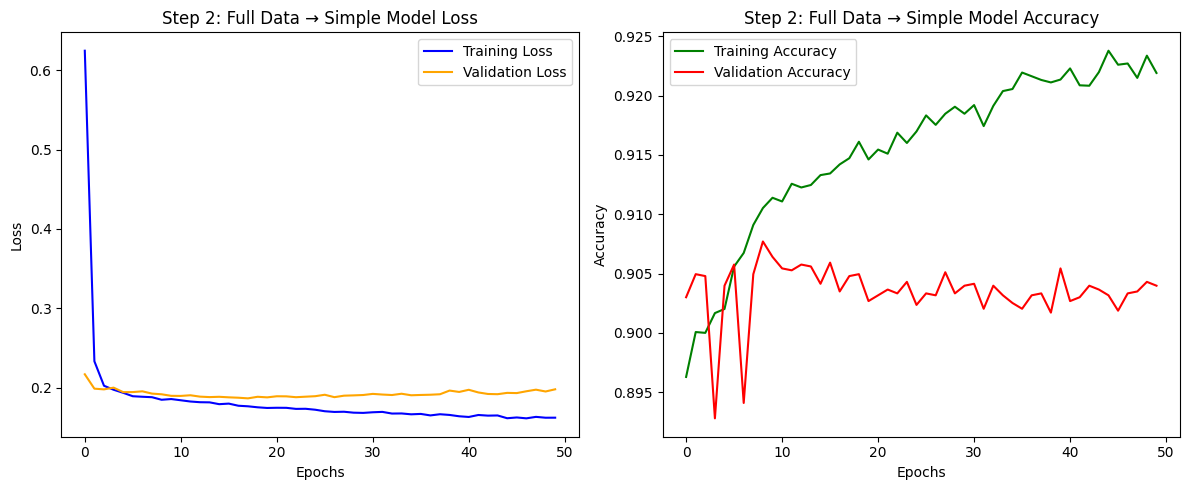

In [43]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_complex_reg.history['loss'], label='Training Loss', color='blue')
plt.plot(history_complex_reg.history['val_loss'], label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Step 2: Full Data → Simple Model Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_complex_reg.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history_complex_reg.history['val_accuracy'], label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Step 2: Full Data → Simple Model Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

With regularization, the model looks healthier — the loss for training and validation drops together and stays close, showing it’s learning without overfitting too much. Training accuracy still rises a bit higher than validation, but the gap is smaller, so the model generalizes better.